In [1]:
using Turing
using Jens, CUDA
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensPlots as Jplots
using Jens:LensCosmo as LC
using Jens:LensPSF as LP

using Jens.LensModel.ComLens: CombinedLens
using Jens.LensModel: NFWE, Shear, SIS
using Jens.LightModel: CompositeImage, ExtendedSource, PointImage, PointImages
using Jens.LightModel.SersicLight: SersicSpheric
using Jens.LensSystem: ForwardModel, render
using Jens.LensSolver: solve_images
using Jens.LensPSO: lens_pso_mh, chain, chain_stats
using Jens.LensUtils: randn_like

[ Info: Precompiling Jens [51b7c8bc-8c55-4cde-95cb-80ce6c4547ac](cache misses: include_dependency fsize change (1))
[ Info: Precompiling Jens [51b7c8bc-8c55-4cde-95cb-80ce6c4547ac] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing Jens [51b7c8bc-8c55-4cde-95cb-80ce6c4547ac].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.
[ Info: Precompiling JensCUDA [b50c7a95-6ca5-5c7e-ae97-b6132035395f](cache misses: wrong dep version loaded (1))
[ Info: Precompiling JensCUDA [b50c7a95-6ca5-5c7e-ae97-b6132035395f] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a f

In [2]:
# Cosmology + grid + PSF 
cosmo = LC.Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)
z_lens, z_src = 0.3, 1.5

grid_cpu = LG.GenGrid(pix_n=64, pix_size=0.06)              # CPU
grid_gpu = gpu_grid(pix_n=64, pix_size=Float32(0.06))  # GPU

psf = LP.GaussianPSF(; fwhm=0.1)

Jens.LensPSF.GaussianPSF{Float64}(0.1)

In [3]:
# Lens model
lens = CombinedLens(
    NFWE   => (Rs=3.5, alpha_Rs=1.0, e1=0.2, e2=0.1, xcentre=0.0, ycentre=0.0),
    Shear => (gamma1=0.05, gamma2=-0.03, xcentre=0.0, ycentre=0.0))

CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{Rs::Float64, alpha_Rs::Float64, e1::Float64, e2::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64, xcentre::Float64, ycentre::Float64}}}((Jens.LensModel.NFWE, Jens.LensModel.Shear), ((Rs = 3.5, alpha_Rs = 1.0, e1 = 0.2, e2 = 0.1, xcentre = 0.0, ycentre = 0.0), (gamma1 = 0.05, gamma2 = -0.03, xcentre = 0.0, ycentre = 0.0)))

In [4]:
agn_images = solve_images(lens, 0.01, -0.03; z_source=z_src)
agn_positions = [(x, y) for (x, y, _) in agn_images]

5-element Vector{Tuple{Float64, Float64}}:
 (-0.005325399976989112, 0.013757428240454528)
 (0.32771412772178055, 0.17765751165743549)
 (-0.2134353558457285, 0.5248657854409159)
 (-0.3859138648504492, -0.06598118613428537)
 (0.2572722101005293, -0.6371080224807752)

In [5]:
# Light model
# host
host = ExtendedSource(SersicSpheric;
    amp=2.0, Rsersic=0.3, n=2.0, xcentre=0.01, ycentre=-0.01)

# point source
agn =  PointImages((2.0, agn_positions); intrinsic=true)

# combine
src = CompositeImage(host, agn)

CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImages{Float64}}}((ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 2.0, Rsersic = 0.3, n = 2.0, xcentre = 0.01, ycentre = -0.01)), PointImages{Float64}([(2.0, [(-0.005325399976989112, 0.013757428240454528), (0.32771412772178055, 0.17765751165743549), (-0.2134353558457285, 0.5248657854409159), (-0.3859138648504492, -0.06598118613428537), (0.2572722101005293, -0.6371080224807752)])], true)))

In [23]:
sys = ForwardModel(
    lens_plane   = LG.LensedPlane(lens; z_lens, cosmology=cosmo),
    source_plane = LG.LightPlane(src; z=z_src),
    grid = grid_gpu, psf = psf,
)

@time img = render(sys);

  0.016595 seconds (5.49 k allocations: 948.867 KiB)


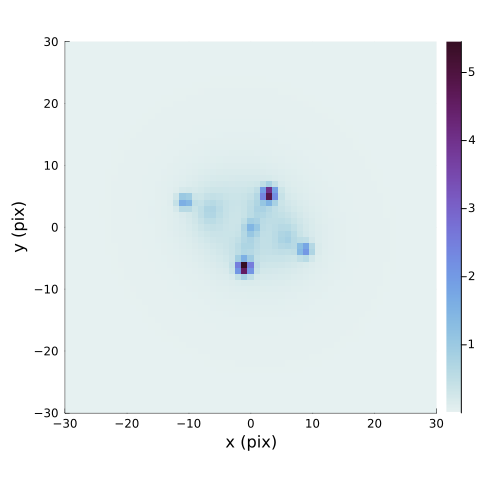

In [7]:
canvas = Jplots.LensCanvas(;  xlims=(-30,30), ylims=(-30,30),
        size=(500,500))
Jplots.PlotPlane!(canvas, Array(img) )
display(canvas)

In [24]:
# SIM real img
sigma = max(median(abs.(img)) * 0.1, 1e-3)           # noise

data_noisy = img .+ sigma .* randn_like(img);

In [25]:
# likelihood
function build_logp(data, grid, psf, cosmo, z_lens, z_src, agn_pos)
    function logp_fn(p)
        Rs, alpha_Rs, e1, e2, amp, rsr, n, flux, log_sigma = p
        sigma_data = exp(log_sigma)

        (Rs > 0 && alpha_Rs > 0 && rsr > 0 && n > 0.2 && amp > 0 && flux > 0 && sigma_data > 0) || return -Inf
        abs(e1) < 1 && abs(e2) < 1 && e1^2 + e2^2 < 1 || return -Inf

        lens = LG.LensedPlane(CombinedLens(NFWE => (
            Rs=Rs, alpha_Rs=alpha_Rs, e1=e1, e2=e2,
            xcentre=0.0, ycentre=0.0)); z_lens=z_lens, cosmology=cosmo)
        host = ExtendedSource(SersicSpheric; amp=amp, Rsersic=rsr, n=n)
        agn  = PointImages((flux, agn_pos); intrinsic=true)

        fwd  = ForwardModel(lens_plane=lens,
            source_plane=LG.LightPlane(CompositeImage(host, agn); z=z_src), grid=grid, psf=psf)
        img = try render(fwd) catch; return -Inf end

        N = length(data)
        logp = -N * log(sigma_data) - 0.5 * sum(((data .- img) ./ sigma_data).^2)
        # Jacobian: uniform prior on sigma → +log_sigma in log-space
        logp += log_sigma
        return logp
    end
    return logp_fn
end

build_logp (generic function with 1 method)

In [26]:
logp = build_logp(data_noisy, grid_gpu, psf, cosmo, z_lens, z_src, agn_positions)

(::var"#logp_fn#build_logp##4"{CuArray{Float64, 2, CUDACore.DeviceMemory}, JensCUDA.GridGPU{CuArray{Float32, 2, CUDACore.DeviceMemory}}, Jens.LensPSF.GaussianPSF{Float64}, Cosmology.FlatLCDM{Float64}, Float64, Float64, Vector{Tuple{Float64, Float64}}}) (generic function with 1 method)

In [27]:
using Jens.LensMH: lens_mh_multistart, chain
# prior bounds 
#          Rs     α_Rs    e1      e2     amp    Rsrs    n     flux  log_sigma
lower_n = [1.0,   1.0,    -0.4,   -0.4,  0.2,   0.08,  0.5,   1.0,  log(0.001)]
upper_n = [5.0,   3.5,     0.4,    0.4,  3.0,   0.8,   5.0,   5.0,  log(0.5)]
#init  = [5.5, 0.9, 0.35]


@time res = lens_mh_multistart(logp, lower_n, upper_n; n_starts=8, n=1000, seed=42)

  2.719309 seconds (13.21 M allocations: 1.609 GiB, 6.77% gc time, 55.98% compilation time: <1% of which was recompilation)


Jens.LensMH.MHResult([3.055221523374921 3.055221523374921 … 3.173587605370175 3.174418997988597; 1.8782233338638041 1.8782233338638041 … 1.924868256998481 1.9254145065184645; … ; 1.3616984202954765 1.3616984202954765 … 1.5391707719636265 1.5392085333088221; -2.194388677805864 -2.194388677805864 … -2.2239971905491087 -2.2250244002345823], [7243.821343378087, 7243.821343378087, 7243.821343378087, 7243.821343378087, 7243.821343378087, 7243.821343378087, 7243.821343378087, 7243.821343378087, 7243.821343378087, 7243.821343378087  …  7327.7385971964095, 7327.7385971964095, 7327.7385971964095, 7327.7385971964095, 7329.519706706019, 7329.519706706019, 7329.519706706019, 7329.519706706019, 7329.519706706019, 7327.608660005327], 179, [0.00204, 0.001275, 0.00040800000000000005, 0.00040800000000000005, 0.001428, 0.00036720000000000004, 0.0022949999999999997, 0.00204, 0.0031694501301953175])

In [29]:
# summary
summary = chain(res; burn=100)          # (n_params, n_samples) 
means, stds = chain_stats(res; burn=100)

([3.1461134408152556, 1.9163259742766632, -0.10807847877441076, -0.04131156660877125, 2.956294869693931, 0.5492596182300913, 3.6577561391128524, 1.5223958332923113, -2.2297867881504123], [0.01760457636114587, 0.005830858249109499, 0.002918179137628258, 0.005212103066299809, 0.014331329545171224, 0.004409069559804365, 0.02176092203912552, 0.019993338598672493, 0.014683198041630282])

In [30]:
using StatsPlots,PairPlots, MCMCChains, CairoMakie

[ Info: Precompiling PairPlots [43a3c2be-4208-490b-832a-a21dcd55d7da](cache misses: wrong dep version loaded (1))
[ Info: Precompiling PairPlots [43a3c2be-4208-490b-832a-a21dcd55d7da] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling GeometryBasicsExt [b238bd29-021f-5edc-8b0e-16b9cda5f63a](cache misses: wrong dep version loaded (1))
[ Info: Precompiling GeometryBasicsExt [b238bd29-021f-5edc-8b0e-16b9cda5f63a] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling BangBangStructArraysExt [d139770a-8b79-56c4-91f8-7273c836fd96](cache misses: wrong dep version loaded (1))
[ Info: Precompiling BangBangStructArraysExt [d139770a-8b79-56c4-91f8-7273c836fd96] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to prin

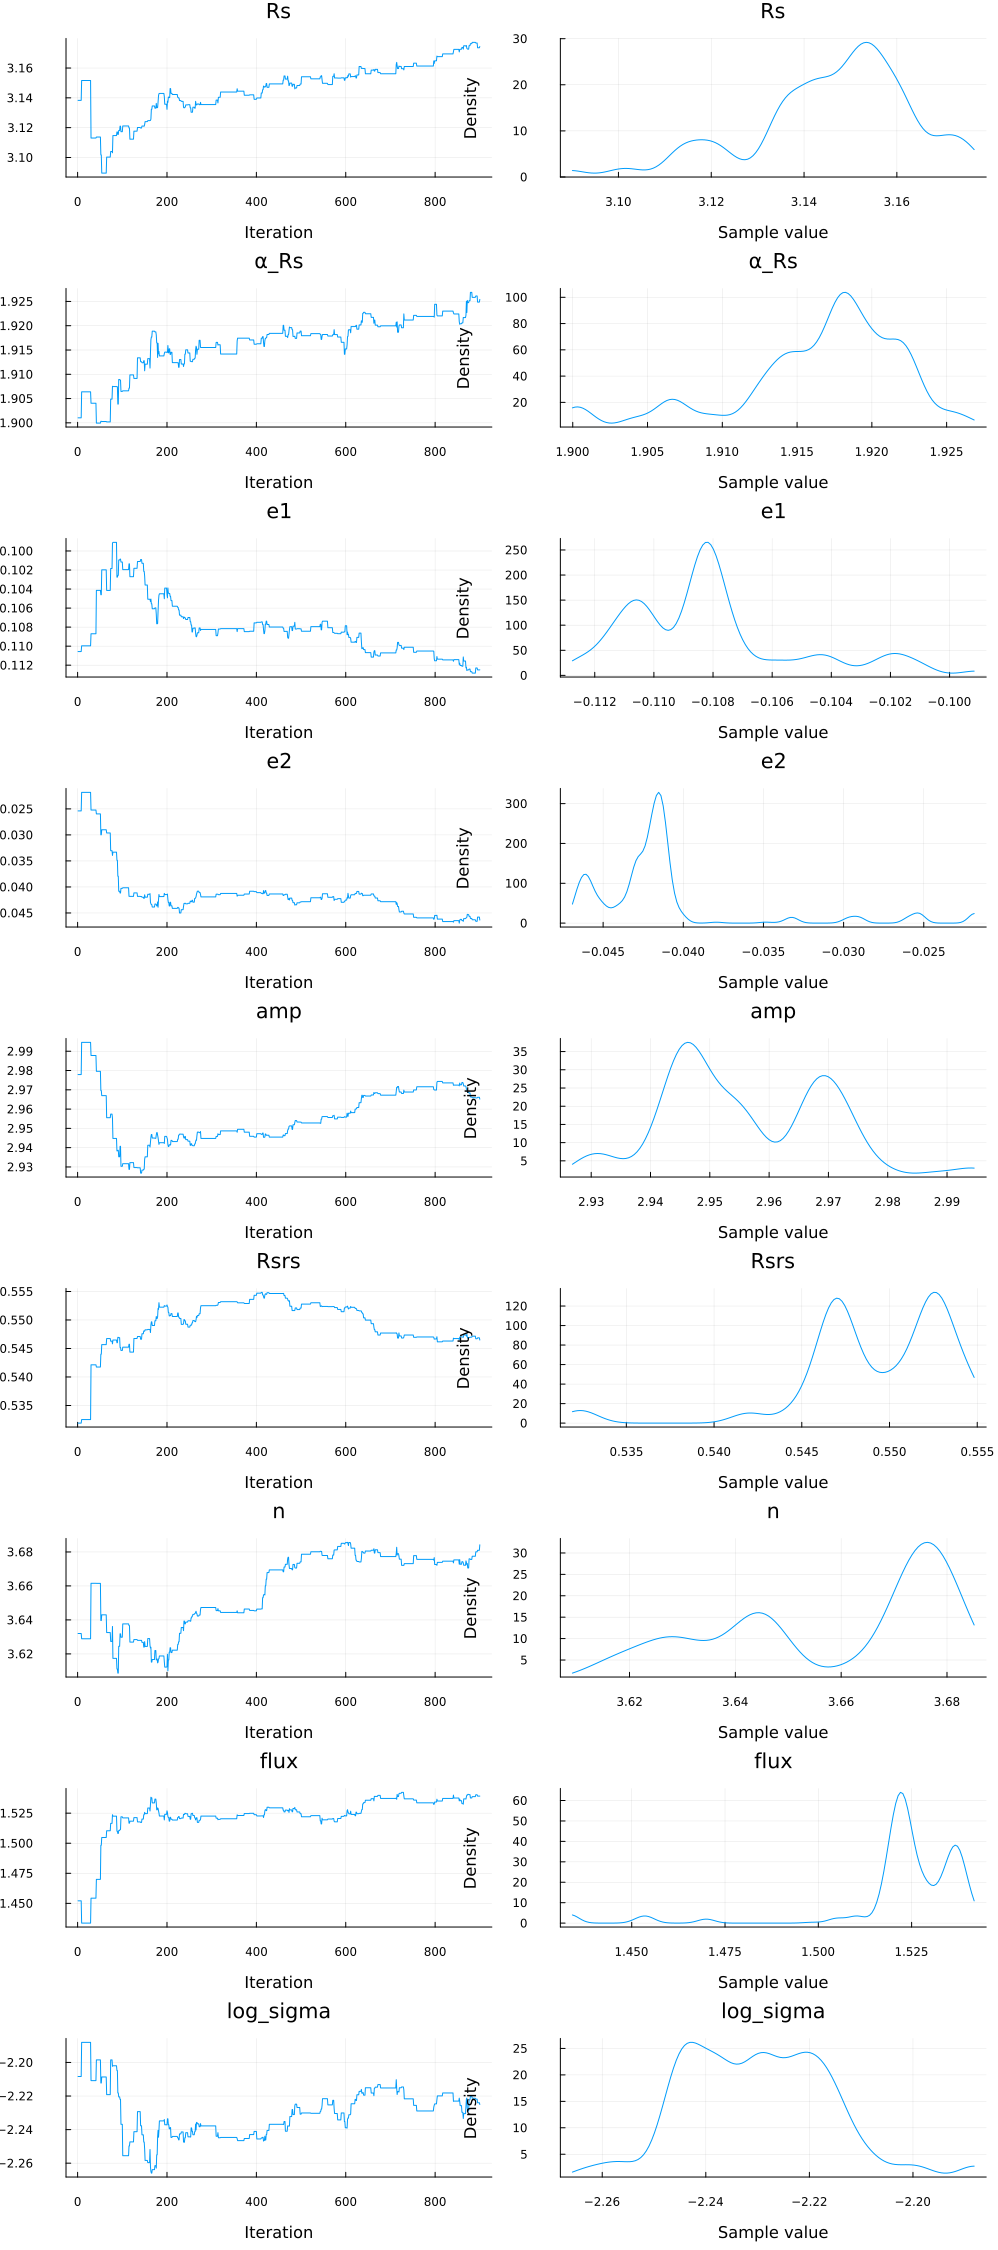

In [32]:
chn = Chains(summary', [:Rs, :α_Rs, :e1, :e2, :amp, :Rsrs, :n, :flux, :log_sigma])
ChainPlot = StatsPlots.plot(chn) 

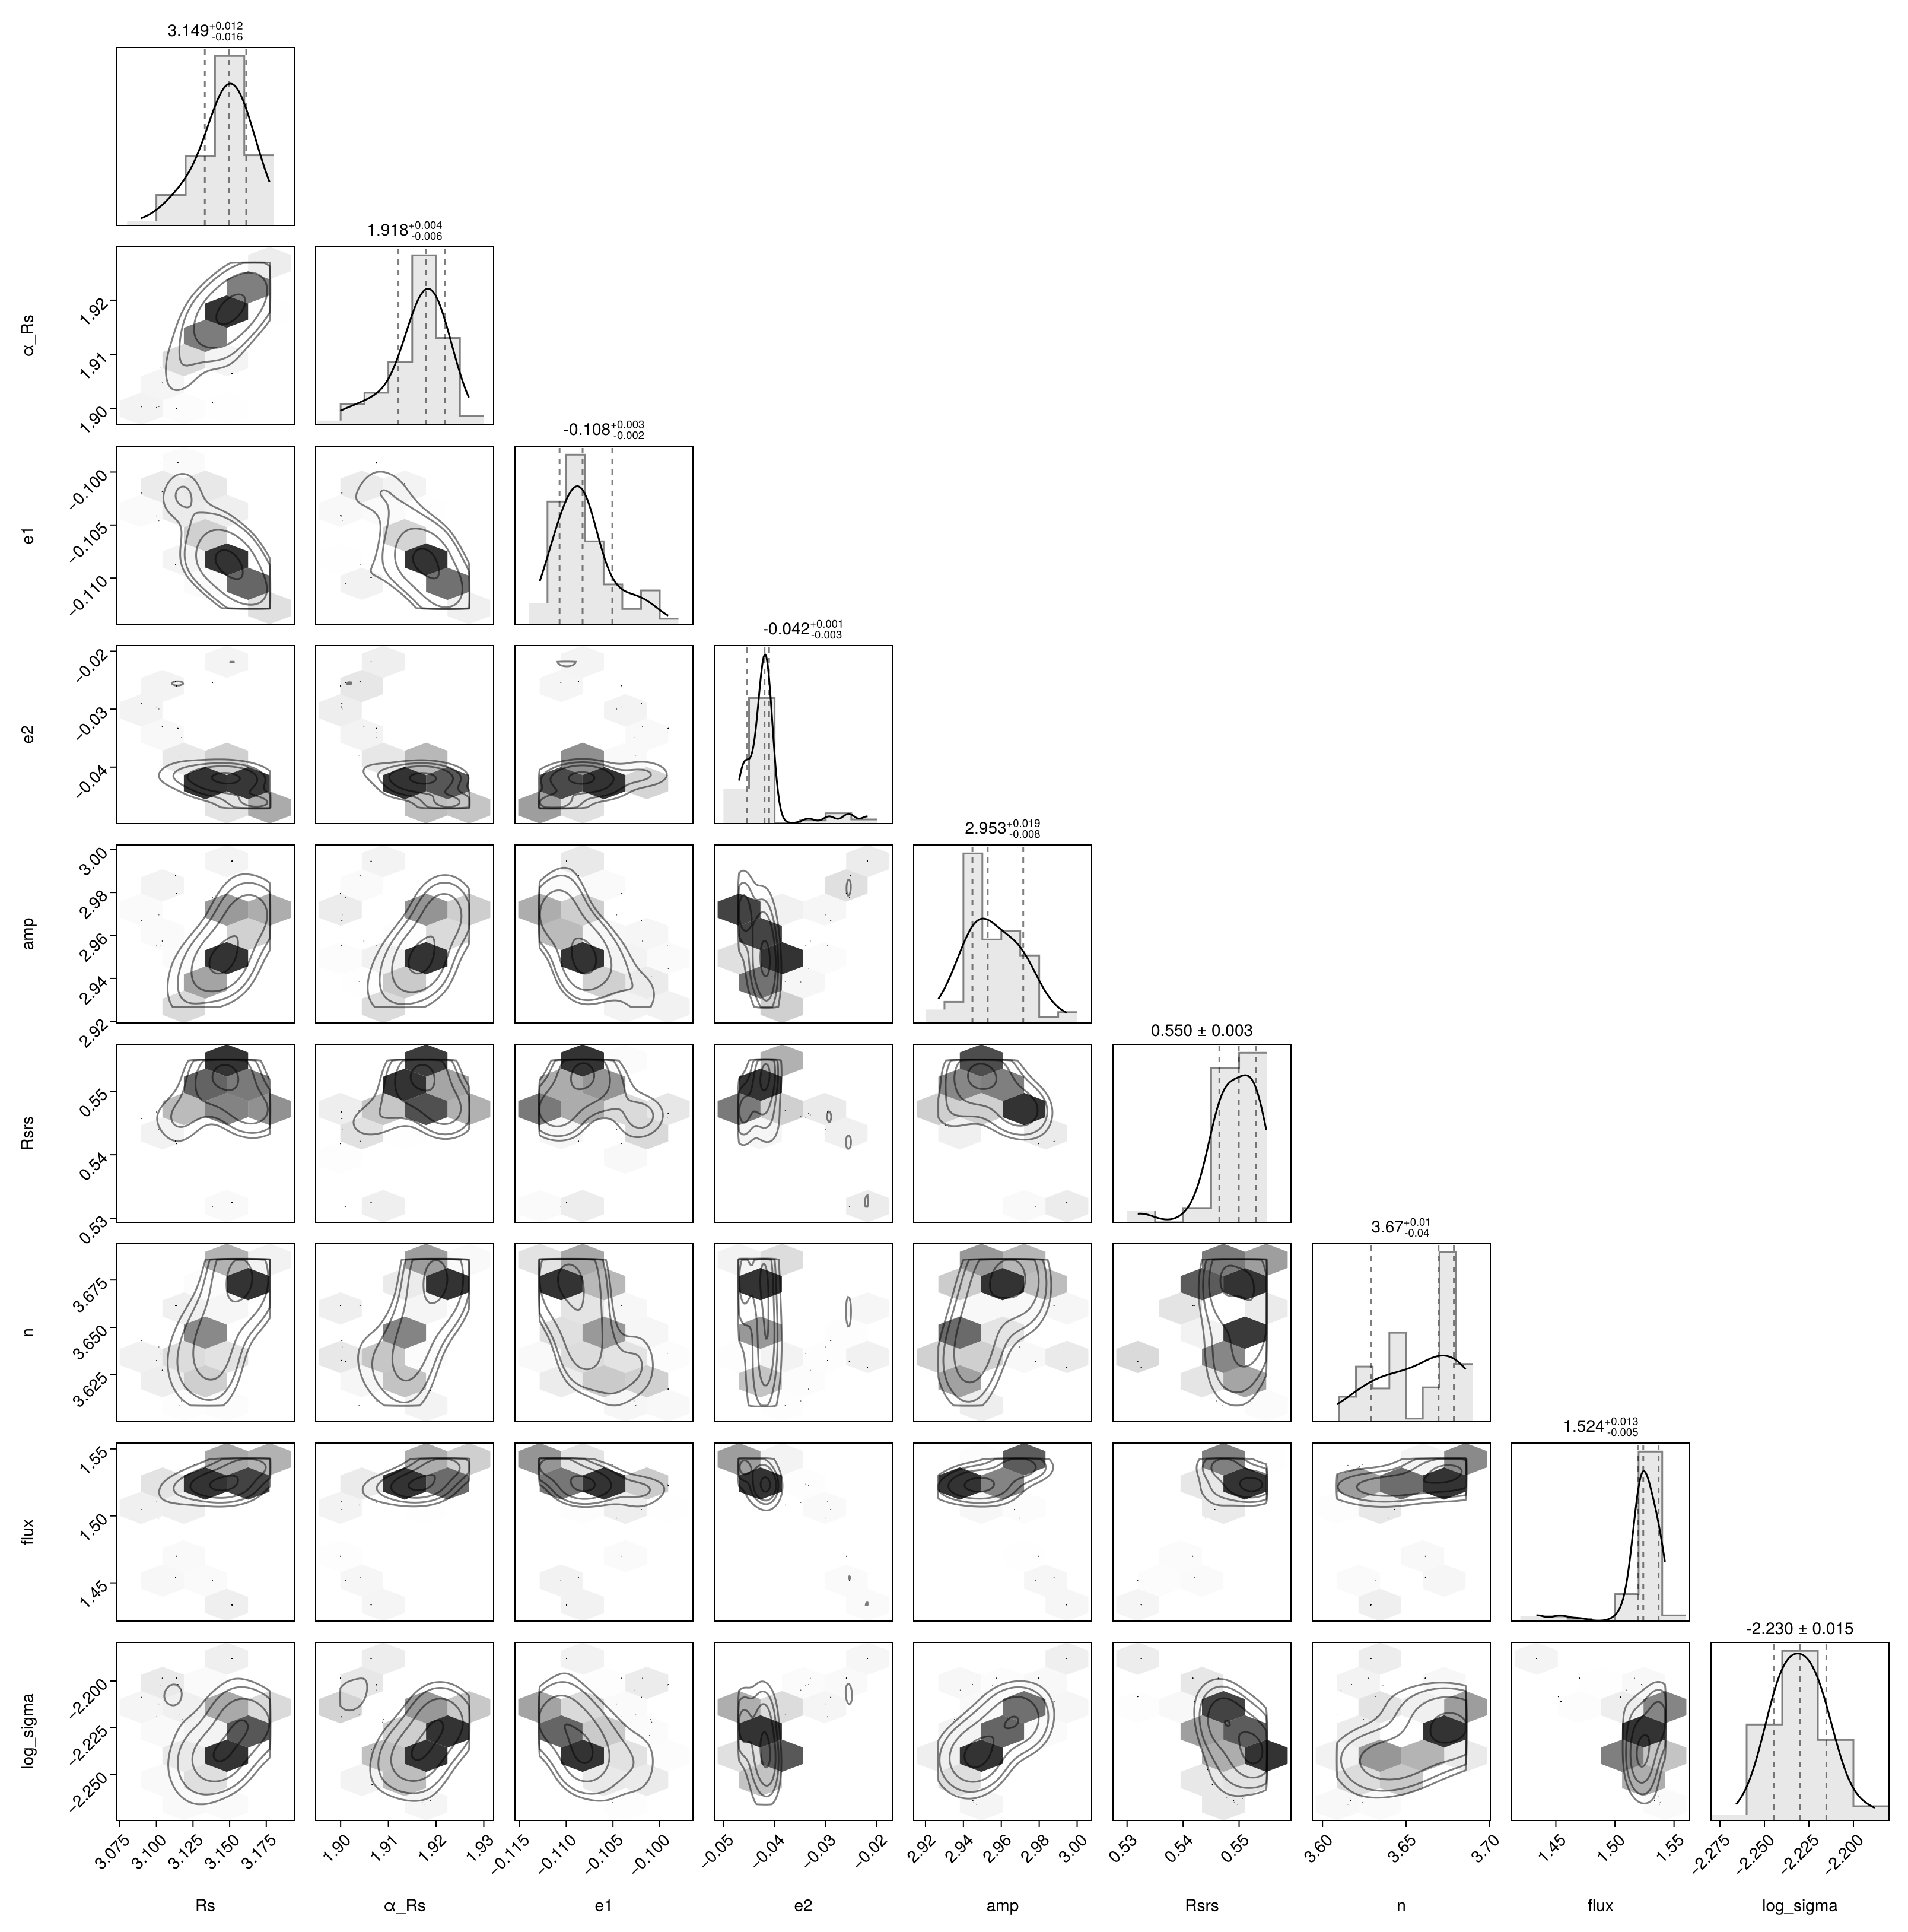

In [33]:
corner_fig = PairPlots.pairplot(chn)


|  MCMC （500 strps MH，3-para SIS）                     |   
|  grid   |   CPU    |    GPU   |   acc  |    ms/step(CPU) | ms/step(GPU)|
|------|------|------|------|------|------|
|   64²  |    0.5 s   |   1.7 s  |  0.3  |    1.0    |     3.4|
|  128²   |   0.8 s  |    0.3 s  |  2.7    |     1.7   |      0.6|
|  256²   |   6.9 s   |   0.4 s  | 19.1   |  13.9    |     0.7|